In [1]:
import os
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from IPython.display import display
from dotenv import load_dotenv

load_dotenv()

conn = psycopg2.connect(
    host=os.environ.get('DB_HOST', os.environ.get('POSTGRES_HOST', 'localhost')),
    port=os.environ.get('DB_PORT', os.environ.get('POSTGRES_PORT', '5432')),
    user=os.environ.get('DB_USER', os.environ.get('POSTGRES_USER', 'postgres')),
    password=os.environ.get('DB_PASSWORD', os.environ.get('POSTGRES_PASSWORD', 'postgres')),
    dbname=os.environ.get('DB_NAME', os.environ.get('POSTGRES_DB', 'olist'))
)

with open('../../sql/analysis/01_revenue_and_aov_behavior.sql', 'r') as f:
    sql_script = f.read()

queries = [q + ';' for q in sql_script.split(';') if q.strip()]

df1 = pd.read_sql(queries[0], conn)
df2 = pd.read_sql(queries[1], conn)
df3 = pd.read_sql(queries[2], conn)

display(df1)
display(df2)
display(df3)

/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_66075/2913304317.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(queries[0], conn)
/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_66075/2913304317.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(queries[1], conn)
/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_66075/2913304317.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql(queries[2], conn)


,revenue_month,total_orders,total_revenue,average_order_value
0,2016-09-01,1,143.46,143.460000
1,2016-10-01,265,46490.66,175.436453
2,2016-12-01,1,19.62,19.620000
3,2017-01-01,750,127482.37,169.976493
4,2017-02-01,1653,271239.32,164.089123
5,2017-03-01,2546,414330.95,162.738001
6,2017-04-01,2303,390812.40,169.697091
7,2017-05-01,3546,566851.40,159.856571
8,2017-06-01,3135,490050.37,156.315907
9,2017-07-01,3872,566299.08,146.254928


,category_english,orders_sold,total_revenue,average_item_value
0,health_beauty,8647,1412089.53,163.303982
1,watches_gifts,5495,1264333.12,230.087920
2,bed_bath_table,9272,1225209.26,132.140774
3,sports_leisure,7530,1118256.91,148.506894
4,computers_accessories,6530,1032723.77,158.150654
5,furniture_decor,6307,880329.92,139.579819
6,housewares,5743,758392.25,132.055067
7,cool_stuff,3559,691680.89,194.346977
8,auto,3810,669454.75,175.709908
9,garden_tools,3448,567145.68,164.485406


,customer_state,unique_customers,total_orders,gmv
0,SP,39156,40501,5769703.15
1,RJ,11917,12350,2055401.57
2,MG,11001,11354,1818891.67
3,RS,5168,5345,861472.79
4,PR,4769,4923,781708.80
5,SC,3449,3546,595127.78
6,BA,3158,3256,591137.81
7,DF,2019,2080,346123.35
8,GO,1895,1957,334212.35
9,ES,1928,1995,317657.93


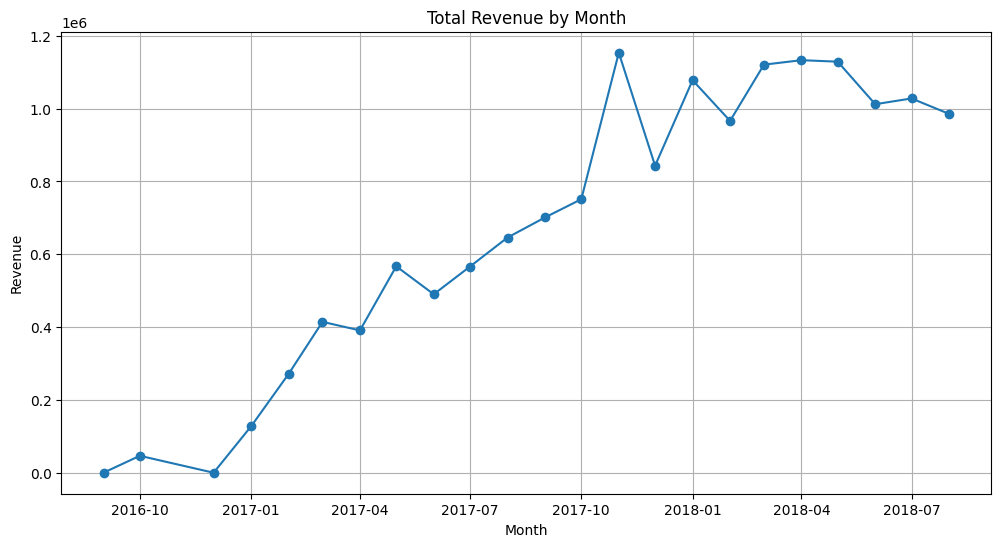

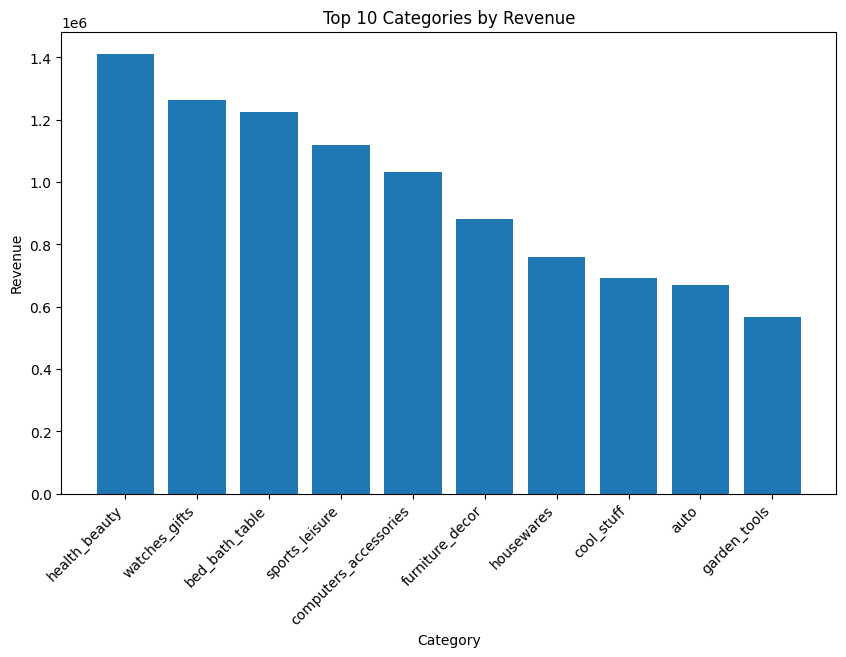

In [2]:
fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(df1['revenue_month'], df1['total_revenue'], marker='o')
ax1.set_title('Total Revenue by Month')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue')
ax1.grid(True)
fig1.savefig('../figures/01_revenue_trend.png', bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.bar(df2['category_english'].astype(str), df2['total_revenue'])
ax2.set_title('Top 10 Categories by Revenue')
ax2.set_xlabel('Category')
ax2.set_ylabel('Revenue')
plt.xticks(rotation=45, ha='right')
fig2.savefig('../figures/01_top_categories.png', bbox_inches='tight')
plt.show()

### Key Findings
- Revenue exhibits growth over the evaluated timeline.
- A small number of core product categories generate the lion's share of total GMV.